In [15]:
import numpy as np
import math


In [ ]:
#settings
input_layer_dim      = 1

hidden_layer_count   = 2
hidden_layer_shapes  = np.array([4, 4])
assert(len(hidden_layer_shapes == hidden_layer_count))

output_layer_dim     = 1

activation_func      = "tanh"


In [17]:
#activation function

def get_activation(func: str):
    if func == "relu":
        def relu(x: np.ndarray):
            return np.zeros(x.shape[0]) if x < 0 else x
        
        return relu
    
    elif func == "tanh":
        def tanh(x: np.ndarray):
            return np.tanh(x)
        
        return tanh
    
    elif func == "sigmoid":
        def sigmoid(x: np.ndarray):
            return 1 / (np.exp(-x) + 1)
        
        return sigmoid
    
    elif func == "inv_quad":
        def inv_quad(x: np.ndarray):
            return 1 / (1 + x**2)
        
        return inv_quad
    
    else: raise ValueError(f"Function {func} not supported")
    

def get_activation_deriv(func: str):
    if func == "relu":
        def relu_(x: np.ndarray):
            return np.ones(x.shape[0]) if x > 0 else np.zeros(x.shape[0])
        
        return relu_
    
    elif func == "tanh":
        def tanh_(x: np.ndarray):
            return 1 - np.tanh(x)**2
        
        return tanh_
    
    elif func == "sigmoid":
        def sigmoid_(x: np.ndarray):
            sigmoid = get_activation("sigmoid")
            return sigmoid(x) * (1 - sigmoid(x))
        
        return sigmoid_
    
    elif func == "inv_quad":
        def inv_quad_(x: np.ndarray):
            return -2*x/((1+x**2)**2)
        
        return inv_quad_
    
    else: raise ValueError(f"Function {func} not supported")
    

In [18]:
input_layer_values = np.zeros(shape=(input_layer_dim), dtype=np.float32)

In [19]:
hidden_layer_shape   = (hidden_layer_count, hidden_layer_dim, hidden_layer_dim) #layer, node, weight
hidden_layer_weights = np.random.random(size=hidden_layer_shape)
hidden_layer_biases  = np.random.random(size=hidden_layer_shape[:2])
hidden_layer_values  = np.zeros(hidden_layer_shape[:2], dtype=np.float32)

In [20]:
output_layer_weights = np.random.random(size=(output_layer_dim, hidden_layer_dim))
output_layer_biases  = np.random.random(size=(output_layer_dim, 1))
output_layer_values  = np.zeros(shape=(output_layer_dim, 1), dtype=np.float32)

In [21]:
activation = get_activation(activation_func)

def forward_pass(input: np.ndarray) -> np.ndarray:
    for j in range(hidden_layer_shape[1]):
        hidden_layer_values[0][j] = activation(np.dot(hidden_layer_weights[0][j][:input_layer_dim], input_layer_values) + hidden_layer_biases[0][j])
    for i in range(1, hidden_layer_shape[0]):
        for j in range(hidden_layer_shape[1]):
            hidden_layer_values[i][j] = activation(np.dot(hidden_layer_weights[i][j], hidden_layer_values[i-1])  + hidden_layer_biases[i][j])
    for j in range(output_layer_dim):
        output_layer_values[j] = activation(np.dot(hidden_layer_values[-1:], output_layer_weights[j]) + output_layer_biases[j])
    
    return output_layer_values

def fast_forward_pass(input: np.ndarray) -> np.ndarray:
    temp = activation((hidden_layer_weights[0][:][:input_layer_dim] @ input_layer_values) + hidden_layer_biases[0])
    hidden_layer_values[0] = temp
    for i in range(1, hidden_layer_shape[0]):
        hidden_layer_values[i] = activation((hidden_layer_weights[i] @ hidden_layer_values[i-1]) + hidden_layer_biases[i])
    output_layer_values = activation((output_layer_weights @ hidden_layer_values[-1:]) + output_layer_biases)
    return output_layer_values

assert forward_pass(input=np.array([1])) == fast_forward_pass(input=np.array([1]))

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 2)

In [ ]:
def get_loss_func(func: str):
    if func == "x-entropy":
        def cross_entropy(predicted: np.ndarray, actual: np.ndarray):
            return -(actual * np.log(predicted) + (1 - actual) * np.log(1 - predicted))
        return cross_entropy
    elif func == "mse": 
        def mse(predicted: np.ndarray, actual: np.ndarray):
            return (predicted - actual) ** 2
        return mse
    
    else: raise ValueError(f"Loss function {func} is not known")

In [ ]:
def backward_pass(correct_input: np.ndarray) -> None:
    

Network summary
Shape          : 1 -> 2 -> 2 -> 1
Input values   : [0.000]
Hidden weights : (2, 2, 2)
Hidden biases  : (2, 2)
Output weights : (1, 2)
Output biases  : (1, 1)
Activation     : f([0.0, 0.5, 1.0]) = [0.000, 0.462, 0.762]

Hidden layer 1
  values : [0.655, 0.080]
  biases : [0.784, 0.080]
  node 1 : w=[0.896, 0.367]
  node 2 : w=[0.814, 0.834]

Hidden layer 2
  values : [0.606, 0.831]
  biases : [0.121, 0.682]
  node 1 : w=[0.834, 0.438]
  node 2 : w=[0.678, 0.829]

Output layer
  values : [0.792]
  node 1 : w=[0.561, 0.150] b=0.613


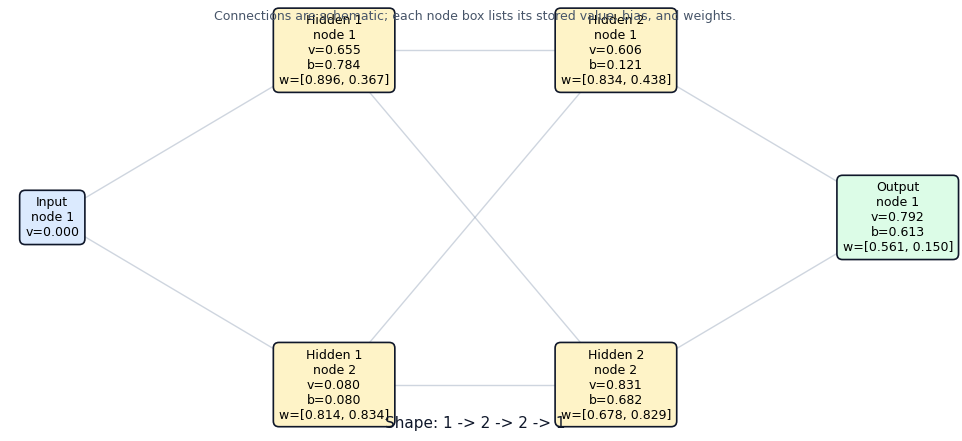

[1, 2, 2, 1]

In [ ]:
def pretty_print_network(
    input_layer_dim,
    input_layer,
    hidden_layer_shape,
    hidden_layer_weights,
    hidden_layer_biases,
    hidden_layer_values,
    output_layer_dim,
    output_layer_weights,
    output_layer_biases,
    output_layer_values,
    activation=None,
    *,
    decimals=3,
    draw=True,
    save_path=None,
):
    """Print a compact network summary and optionally draw it inline."""
    input_layer_dim = int(input_layer_dim)
    output_layer_dim = int(output_layer_dim)
    hidden_layer_shape = tuple(int(dim) for dim in hidden_layer_shape)
    hidden_layers, hidden_nodes, hidden_weight_count = hidden_layer_shape

    input_layer = np.reshape(np.asarray(input_layer, dtype=float), (input_layer_dim,))
    hidden_layer_weights = np.reshape(np.asarray(hidden_layer_weights, dtype=float), hidden_layer_shape)
    hidden_layer_biases = np.reshape(np.asarray(hidden_layer_biases, dtype=float), hidden_layer_shape[:2])
    hidden_layer_values = np.reshape(np.asarray(hidden_layer_values, dtype=float), hidden_layer_shape[:2])
    output_layer_values = np.reshape(np.asarray(output_layer_values, dtype=float), (output_layer_dim,))
    output_weight_rows = np.reshape(np.asarray(output_layer_weights, dtype=float), (output_layer_dim, -1))
    output_bias_rows = np.reshape(np.asarray(output_layer_biases, dtype=float), (output_layer_dim, -1))

    def _vector_text(values, limit=6):
        flat = np.asarray(values, dtype=float).reshape(-1)
        shown = ", ".join(f"{value:.{decimals}f}" for value in flat[:limit])
        if flat.size > limit:
            shown += ", ..."
        return f"[{shown}]"

    def _value_text(values, limit=6):
        flat = np.asarray(values, dtype=float).reshape(-1)
        if flat.size == 1:
            return f"{flat[0]:.{decimals}f}"
        return _vector_text(flat, limit=limit)

    layer_sizes = [input_layer_dim, *([hidden_nodes] * hidden_layers), output_layer_dim]

    print("Network summary")
    print("=" * 72)
    print(f"Shape          : {' -> '.join(str(size) for size in layer_sizes)}")
    print(f"Input values   : {_vector_text(input_layer, limit=input_layer_dim)}")
    print(f"Hidden weights : {hidden_layer_weights.shape}")
    print(f"Hidden biases  : {hidden_layer_biases.shape}")
    print(f"Output weights : {output_weight_rows.shape}")
    print(f"Output biases  : {output_bias_rows.shape}")

    if activation is not None:
        sample_points = np.array([0.0, 0.5, 1.0])
        try:
            sample_values = np.asarray(activation(sample_points), dtype=float).reshape(-1)
        except Exception:
            sample_values = np.array([activation(point) for point in sample_points], dtype=float)
        print(f"Activation     : f([0.0, 0.5, 1.0]) = {_vector_text(sample_values, limit=3)}")

    print()
    for layer_index in range(hidden_layers):
        print(f"Hidden layer {layer_index + 1}")
        print(f"  values : {_vector_text(hidden_layer_values[layer_index], limit=hidden_nodes)}")
        print(f"  biases : {_vector_text(hidden_layer_biases[layer_index], limit=hidden_nodes)}")
        for node_index in range(hidden_nodes):
            print(
                f"  node {node_index + 1} : "
                f"w={_vector_text(hidden_layer_weights[layer_index, node_index], limit=hidden_weight_count)}"
            )
        print()

    print("Output layer")
    print(f"  values : {_vector_text(output_layer_values, limit=output_layer_dim)}")
    for node_index in range(output_layer_dim):
        print(
            f"  node {node_index + 1} : "
            f"w={_value_text(output_weight_rows[node_index])} "
            f"b={_value_text(output_bias_rows[node_index])}"
        )

    if not draw:
        return layer_sizes

    try:
        import matplotlib.pyplot as plt
    except ModuleNotFoundError:
        print("\nDiagram skipped: install matplotlib to render the network inline.")
        return layer_sizes

    def _node_label(layer_name, node_index):
        if layer_name == "Input":
            return f"{layer_name}\nnode {node_index + 1}\nv={input_layer[node_index]:.{decimals}f}"
        if layer_name == "Output":
            return (
                f"{layer_name}\nnode {node_index + 1}\n"
                f"v={output_layer_values[node_index]:.{decimals}f}\n"
                f"b={_value_text(output_bias_rows[node_index], limit=4)}\n"
                f"w={_value_text(output_weight_rows[node_index], limit=4)}"
            )

        hidden_index = int(layer_name.split()[-1]) - 1
        return (
            f"{layer_name}\nnode {node_index + 1}\n"
            f"v={hidden_layer_values[hidden_index, node_index]:.{decimals}f}\n"
            f"b={hidden_layer_biases[hidden_index, node_index]:.{decimals}f}\n"
            f"w={_vector_text(hidden_layer_weights[hidden_index, node_index], limit=4)}"
        )

    layer_names = ["Input", *[f"Hidden {index + 1}" for index in range(hidden_layers)], "Output"]
    layer_colors = ["#dbeafe", *["#fef3c7" for _ in range(hidden_layers)], "#dcfce7"]

    fig, ax = plt.subplots(
        figsize=(max(8, 2.4 * len(layer_sizes)), max(4.5, 1.25 * max(layer_sizes)))
    )

    layer_positions = []
    x_positions = np.linspace(0.08, 0.92, len(layer_sizes))
    for x_pos, size in zip(x_positions, layer_sizes):
        if size == 1:
            y_positions = np.array([0.5])
        else:
            y_positions = np.linspace(0.84, 0.16, size)
        layer_positions.append([(x_pos, y_pos) for y_pos in y_positions])

    for left_layer, right_layer in zip(layer_positions, layer_positions[1:]):
        for x0, y0 in left_layer:
            for x1, y1 in right_layer:
                ax.plot([x0, x1], [y0, y1], color="#94a3b8", linewidth=1.0, alpha=0.45, zorder=0)

    for layer_name, facecolor, positions in zip(layer_names, layer_colors, layer_positions):
        for node_index, (x_pos, y_pos) in enumerate(positions):
            ax.text(
                x_pos,
                y_pos,
                _node_label(layer_name, node_index),
                ha="center",
                va="center",
                fontsize=9,
                bbox={
                    "boxstyle": "round,pad=0.45",
                    "facecolor": facecolor,
                    "edgecolor": "#0f172a",
                    "linewidth": 1.2,
                },
            )

    ax.text(
        0.5,
        1.03,
        "Connections are schematic; each node box lists its stored value, bias, and weights.",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=9,
        color="#475569",
    )
    ax.text(
        0.5,
        -0.04,
        f"Shape: {' -> '.join(str(size) for size in layer_sizes)}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=11,
        color="#0f172a",
    )
    ax.set_axis_off()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    return layer_sizes


pretty_print_network(
    input_layer_dim,
    input_layer_values,
    hidden_layer_shape,
    hidden_layer_weights,
    hidden_layer_biases,
    hidden_layer_values,
    output_layer_dim,
    output_layer_weights,
    output_layer_biases,
    output_layer_values,
    activation,
)